# 선형 회귀 모델과 오차 평가지표

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/bsis0/Downloads/usa_housing.csv")


df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         300 non-null    int64  
 1   Bedrooms      300 non-null    int64  
 2   Bathrooms     300 non-null    float64
 3   SquareFeet    300 non-null    int64  
 4   YearBuilt     300 non-null    int64  
 5   GarageSpaces  300 non-null    int64  
 6   LotSize       300 non-null    float64
 7   ZipCode       300 non-null    int64  
 8   CrimeRate     300 non-null    float64
 9   SchoolRating  300 non-null    int64  
dtypes: float64(3), int64(7)
memory usage: 23.6 KB


In [22]:
df2 = df[df['YearBuilt'] > 2000]

df2.info()

<class 'pandas.DataFrame'>
Index: 54 entries, 9 to 294
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         54 non-null     int64  
 1   Bedrooms      54 non-null     int64  
 2   Bathrooms     54 non-null     float64
 3   SquareFeet    54 non-null     int64  
 4   YearBuilt     54 non-null     int64  
 5   GarageSpaces  54 non-null     int64  
 6   LotSize       54 non-null     float64
 7   ZipCode       54 non-null     int64  
 8   CrimeRate     54 non-null     float64
 9   SchoolRating  54 non-null     int64  
dtypes: float64(3), int64(7)
memory usage: 4.6 KB


In [27]:
# os에 맞는 폰트 적용

import platform
from matplotlib import rc

os_name = platform.system()
if os_name == "Windows":
    rc("font", family="Malgun Gothic")
else:
    rc("font", family="AppleGothic")

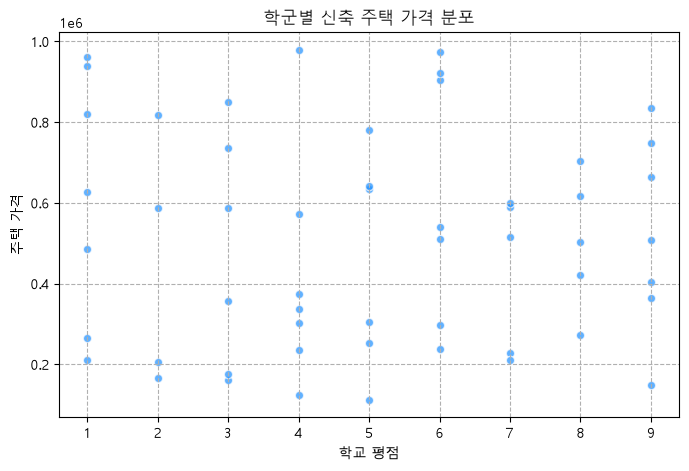

In [29]:
# 학군별 신축 주택 가격 분포 (산점도 생성)

plt.figure(figsize=(8,5))
plt.scatter(df2['SchoolRating'], df2['Price'], color='dodgerblue', alpha = 0.7, edgecolor = 'w')
plt.title('학군별 신축 주택 가격 분포')
plt.xlabel('학교 평점')
plt.ylabel('주택 가격')
plt.grid(True, linestyle='--')
plt.show()

In [35]:
import sklearn
sklearn.set_config(display="text")

In [41]:
# Scikitlearn 라이브러리에서 선형회귀 모델 불러오기
from sklearn.linear_model import LinearRegression

X = df2[['SchoolRating']]
y = df2['Price']

model = LinearRegression()
model.fit(X, y)

# 표가 출력되지 않아서 임의로 출력
print(f"기울기(가중치):{model.coef_}\n절편(편향):{model.intercept_}")


기울기(가중치):[-2216.81807051]
절편(편향):517149.0499464313


In [42]:
# 오차 평가용 MSE와 MAE 불러오기
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred_y = model.predict(X)
pred_y


array([510498.59573491, 499414.50538238, 512715.41380542, 512715.41380542,
       514932.23187592, 514932.23187592, 512715.41380542, 508281.7776644 ,
       510498.59573491, 508281.7776644 , 506064.9595939 , 503848.14152339,
       499414.50538238, 503848.14152339, 499414.50538238, 503848.14152339,
       510498.59573491, 497197.68731187, 508281.7776644 , 506064.9595939 ,
       514932.23187592, 499414.50538238, 508281.7776644 , 497197.68731187,
       497197.68731187, 508281.7776644 , 497197.68731187, 506064.9595939 ,
       508281.7776644 , 514932.23187592, 501631.32345289, 508281.7776644 ,
       503848.14152339, 503848.14152339, 497197.68731187, 512715.41380542,
       503848.14152339, 514932.23187592, 510498.59573491, 510498.59573491,
       506064.9595939 , 506064.9595939 , 503848.14152339, 497197.68731187,
       501631.32345289, 497197.68731187, 501631.32345289, 514932.23187592,
       499414.50538238, 501631.32345289, 506064.9595939 , 514932.23187592,
       501631.32345289, 5

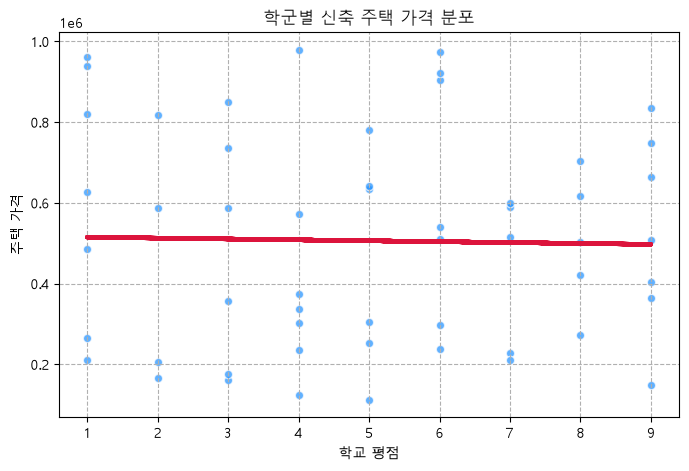

In [44]:
# (산점도 생성) 추가로 예측값 넣기

plt.figure(figsize=(8,5))
plt.scatter(X,y, color='dodgerblue', alpha = 0.7, edgecolor = 'w')
# 회귀 직선 겹쳐 그리기
plt.plot(X, pred_y, color='crimson', linewidth = 3, label="회귀 직선")
plt.title('학군별 신축 주택 가격 분포')
plt.xlabel('학교 평점')
plt.ylabel('주택 가격')
plt.grid(True, linestyle='--')
plt.show()

In [49]:
mse = mean_squared_error(y, pred_y)

mae = mean_absolute_error(y, pred_y)

print(f"오차 제곱 평균:{mse}\n오차 절대값 평균:{mae}")

오차 제곱 평균:66847213624.739105
오차 절대값 평균:222660.70667407376
